# 📊 Matplotlib Basics and Chart Interpretation

**Project:** Retail Sales Analysis (Continued)  
**Duration:** 1.5 – 2 Hours  
**Instructor Notebook — Data Visualization Part 1**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. Understand **why** data visualization is important in EDA
2. Know **which chart to use** for which type of question
3. Create **Line charts, Bar charts, Scatter plots, Histograms, and Boxplots** using Matplotlib
4. Add **labels, titles, legends, and gridlines** to make charts readable
5. Write **simple business insights** from every chart you create

---

## 📌 Prerequisites

You should already be comfortable with:
- Loading data with Pandas
- Data cleaning (handling missing values, duplicates, type conversion)
- Feature engineering (creating new columns, `pd.cut()`, `np.where()`)
- Basic data exploration (`head()`, `describe()`, `value_counts()`, etc.)

---

## 1. What is Data Visualization?

Data visualization means **representing data using charts and graphs** instead of just tables and numbers.

**Think of it this way:**
- A table with 100 rows of revenue data is hard to read.
- A single line chart can instantly show you whether revenue is going **up or down**.

> "A picture is worth a thousand rows of data."

### Why are charts important in EDA?

| Purpose | What you want to know | Best chart |
|---|---|---|
| **Trend** | How does revenue change over time? | Line chart |
| **Comparison** | Which category sells the most? | Bar chart |
| **Relationship** | Does higher price mean higher revenue? | Scatter plot |
| **Distribution** | How is revenue spread across transactions? | Histogram |
| **Outliers** | Are there unusually high or low values? | Boxplot |

**Keep this table handy!** Before creating any chart, always ask yourself:  
*"What question am I trying to answer?"*

---

## 2. What is Matplotlib?

**Matplotlib** is the most popular Python library for creating charts and graphs.

- It was created in 2003 and is still the foundation for most Python plotting.
- We use the `pyplot` module from Matplotlib — commonly imported as `plt`.
- Almost every data science project uses Matplotlib at some stage.

We will use the **simple, beginner-friendly style** of Matplotlib (called the "pyplot" interface).  
This means we call functions like `plt.plot()`, `plt.bar()`, etc. directly.

---

## 3. Import Libraries

In [3]:
# ============================================
# Import the libraries we need
# ============================================
# !pip install matplotlib
# !pip install  openpyxl
import pandas as pd                        # For data handling
import numpy as np                         # For numerical operations
import matplotlib.pyplot as plt            # For creating charts


print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---

## 4. Load the Dataset

In [4]:
# ============================================
# Load the Retail Sales dataset
# ============================================

df = pd.read_excel("DataSet_used/sales_data.xlsx")

# Quick look at the data
print("Shape of data:", df.shape)
df.head()

Shape of data: (85, 13)


,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


---

## 6. Understanding the Basic Chart Structure

Every Matplotlib chart follows these steps:

```python
# Step 1: Set the figure size (optional but recommended)
plt.figure(figsize=(10, 5))

# Step 2: Create the chart
plt.plot(x_data, y_data)

# Step 3: Add labels and title
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Chart Title')

# Step 4: Show the chart
plt.show()
```

**Key points:**
- `plt.figure(figsize=(width, height))` — controls chart size in inches
- `plt.xlabel()`, `plt.ylabel()` — label the axes so people know what they're looking at
- `plt.title()` — give every chart a clear title
- `plt.show()` — displays the chart

Let's now create each chart type one by one!

---

## 7. Line Chart — For Trends Over Time 📈

**When to use:** When you want to see how something **changes over time**.  
**Business question:** *"How does daily revenue change throughout the month?"*

In [5]:
# ============================================
# Prepare data: Total revenue per day
# ============================================

# Group by Date, sum up revenue for each day
daily_revenue = df.groupby('Date')['Revenue'].sum()

# Let's look at this data before plotting
print("Daily Revenue (first 5 days):")
print(daily_revenue)
print("\nTotal days:", len(daily_revenue))

Daily Revenue (first 5 days):
Date
2026-01-01     1200
2026-01-02     5400
2026-01-03     3600
2026-01-04     5400
2026-01-05      150
2026-01-06     5150
2026-01-07     4850
2026-01-08     5650
2026-01-09      550
2026-01-10     2000
2026-01-11      750
2026-01-12     4500
2026-01-14     2400
2026-01-15     7550
2026-01-16     1600
2026-01-17      600
2026-01-18     4600
2026-01-19     2400
2026-01-20     6400
2026-01-21    10750
2026-01-22     8800
2026-01-23     4600
2026-01-24      700
2026-01-25     1400
2026-01-26     3200
2026-01-28     2850
2026-01-29     9450
2026-01-30     9000
2026-01-31     1600
Name: Revenue, dtype: int64

Total days: 29


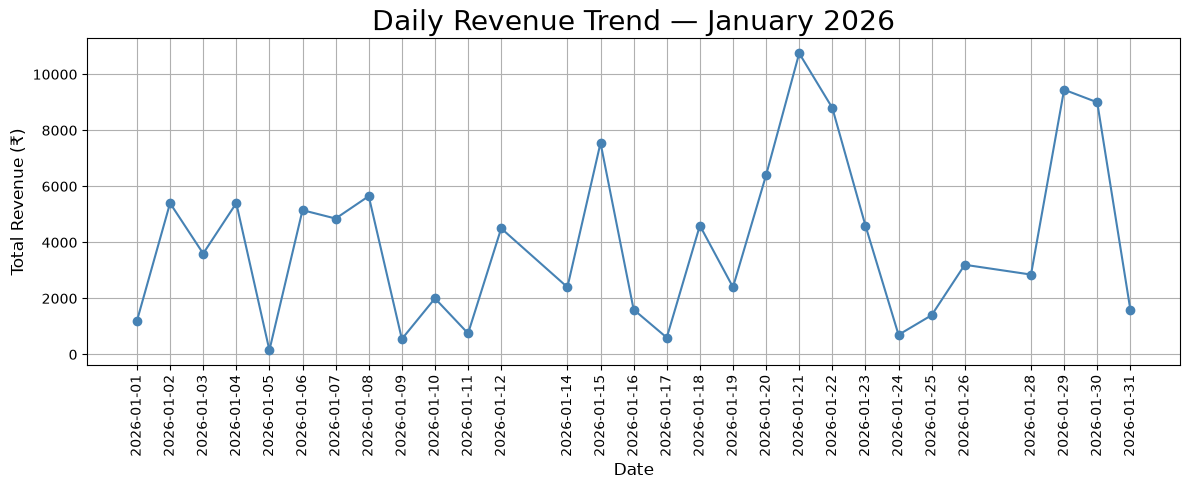

In [6]:
# ============================================
# LINE CHART: Revenue trend by date
# ============================================

# Step 1: Set figure size
plt.figure(figsize=(12, 5))

# Step 2: Create line chart
plt.plot(daily_revenue.index, daily_revenue.values,color='steelblue', marker='o')

# Step 3: Add labels and title
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.title('Daily Revenue Trend — January 2026', fontsize=20)

# Step 4: Add grid for easier reading
plt.grid(True)

# Step 5: Rotate x-axis date labels so they don't overlap
plt.xticks(daily_revenue.index,rotation=90)

# Step 6: Adjust layout so nothing gets cut off
plt.tight_layout()

# Step 7: Show the chart
plt.show()

### 📝 How to Read This Chart

- The **x-axis** shows dates and the **y-axis** shows total revenue.
- Each **dot** represents one day's total revenue.
- **Upward slopes** mean revenue is increasing; **downward slopes** mean it's decreasing.
- Look for **peaks** (best days) and **dips** (slowest days).

### 💡 Sample Business Insight

> *"Revenue fluctuates throughout January. We can see some peak days where revenue was significantly higher — these could correspond to weekends or promotional events. The business could investigate what drove those spikes."*

---

**Tip for writing insights:**
1. What does the chart show? (Describe the trend)
2. What stands out? (Any peaks, dips, or patterns?)
3. Why might this matter for the business?

---

## 8. Bar Chart — For Comparison 📊

**When to use:** When you want to **compare values across categories**.  
**Business question:** *"Which product generates the most revenue?"*

In [7]:
# ============================================
# Prepare data: Revenue by Product
# ============================================

# Group by Product, sum up revenue
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=True)

print("Revenue by Product:")
print(product_revenue)

Revenue by Product:
Product
Headphones     5700
Smartwatch     9000
Tablet        19600
Smartphone    22800
Laptop        60000
Name: Revenue, dtype: int64


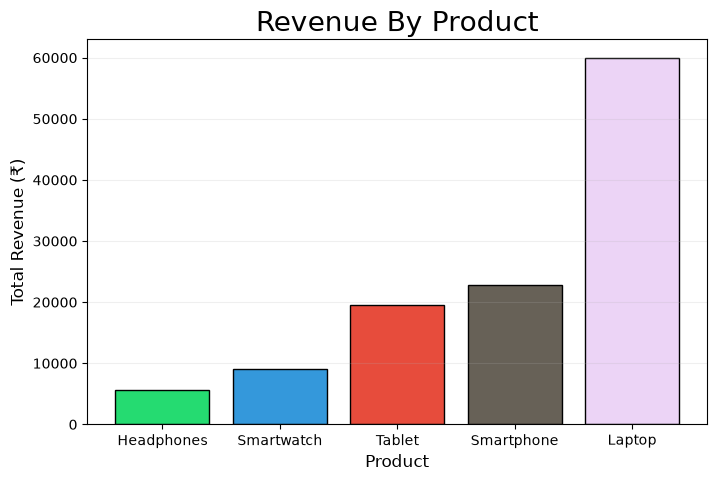

In [8]:
# ============================================
# BAR CHART: Revenue by Product
# ============================================

# Set figure size
plt.figure(figsize=(8, 5))

# Create bar chart with custom colors
colors = ["#25db71", '#3498db', '#e74c3c', "#676157", "#ecd4f6"]
plt.bar(product_revenue.index, product_revenue.values, color=colors, edgecolor='black')

# Add labels and title
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.title('Revenue By Product',fontsize=20)
# Add grid on y-axis for easier comparison
plt.grid(axis='y', alpha=0.2)

# plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- Each **bar** represents one product.
- The **height** of the bar shows total revenue for that product.
- Bars are sorted from highest to lowest revenue (we did `sort_values(ascending=False)`).

### 💡 Sample Business Insight

> *"Laptop generates the highest revenue, which makes sense given its higher price point. The business should ensure sufficient Laptop stock to maintain this revenue stream."*

Category
Accessories     14700
Electronics    102400
Name: Revenue, dtype: int64


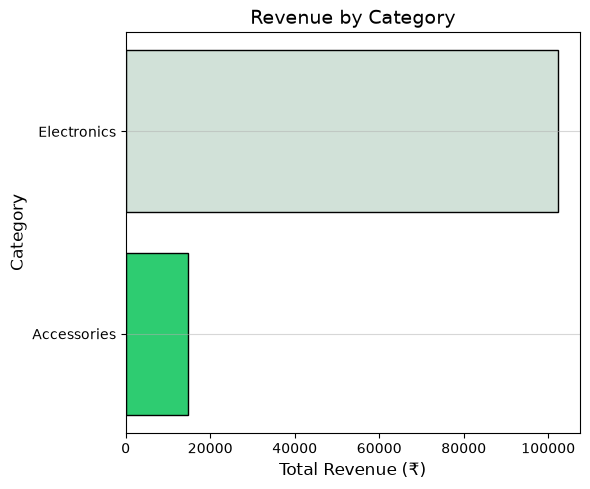

In [9]:
# ============================================
# BAR CHART #2: Revenue by Category
# ============================================

# Group by Category
category_revenue = df.groupby('Category')['Revenue'].sum()
print(category_revenue)
plt.figure(figsize=(6, 5))

# Horizontal bar chart using barh() — useful when labels are long
plt.barh(category_revenue.index, category_revenue.values, color=['#2ecc71',"#d1e1d8"], edgecolor='black')

plt.xlabel('Total Revenue (₹)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('Revenue by Category', fontsize=14)
plt.grid(axis='y',alpha=0.5)

plt.tight_layout()
plt.show()

### 💡 Sample Business Insight

> *"Electronics category dominates revenue compared to Accessories. This is expected since Electronics includes higher-priced items like Laptops and Smartphones."*

---

## 9. Scatter Plot — For Relationships 🔵

**When to use:** When you want to check if there is a **relationship between two numeric columns**.  
**Business question:** *"Is there a relationship between Price and Revenue?"*

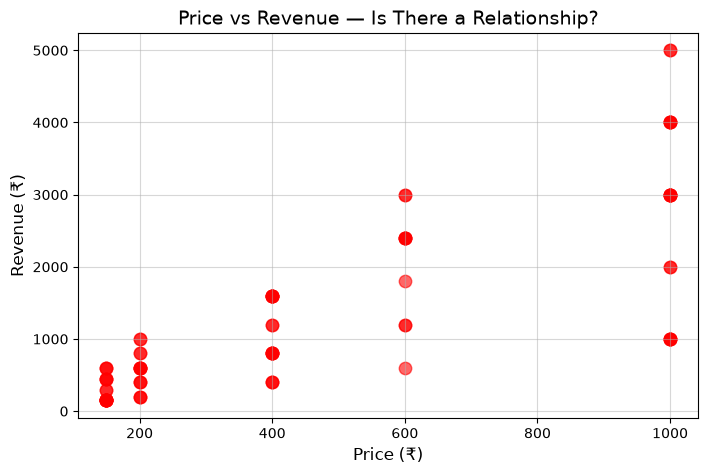

In [10]:
# ============================================
# SCATTER PLOT: Price vs Revenue
# ============================================

plt.figure(figsize=(8, 5))
# x=[1,2,3,4,5,6,7,8,9,10]
# y=[11,20,23,16,5,10,45,23,14,25]
# Each dot = one transaction
plt.scatter(df["Price"],df["Revenue"], color='red', alpha=0.6, s=80)

# alpha=0.6 makes dots slightly transparent so overlapping dots are visible
# s=60 controls dot size

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Price vs Revenue — Is There a Relationship?', fontsize=14)
plt.grid(True, alpha=0.5)

plt.show()

### 📝 How to Read This Chart

- Each **dot** represents one transaction.
- **x-axis** = Price of the product, **y-axis** = Revenue from that transaction.
- If dots go **upward from left to right**, it means higher price tends to mean higher revenue (**positive relationship**).
- If dots are **scattered randomly**, there is **no clear relationship**.

### 💡 Sample Business Insight

> *"There is a general positive trend — higher-priced products tend to generate higher revenue. However, revenue also depends on quantity sold, so some lower-priced items with high quantity can also generate good revenue."*

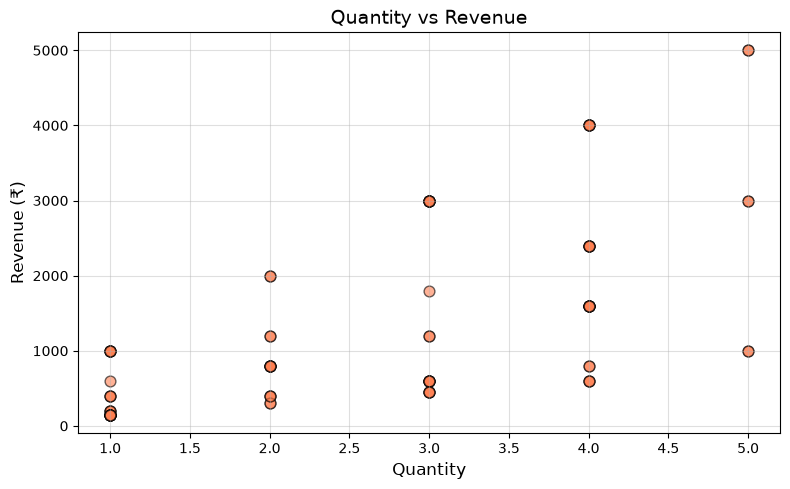

In [11]:
# ============================================
# SCATTER PLOT #2: Quantity vs Revenue
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(df['Quantity'], df['Revenue'], color='coral', alpha=0.6, edgecolors='black', s=60)

plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Quantity vs Revenue', fontsize=14)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---

## 10. Histogram — For Distribution 📊

**When to use:** When you want to see **how values are distributed** — are they clustered, spread out, or skewed?  
**Business question:** *"How is revenue distributed across all transactions?"*

**Histogram vs Bar Chart — What's the difference?**
| Feature | Bar Chart | Histogram |
|---|---|---|
| Used for | Comparing categories | Showing distribution of numbers |
| X-axis | Category labels (Product, City) | Number ranges (bins) |
| Bars touch? | No (gaps between bars) | Yes (bars are connected) |

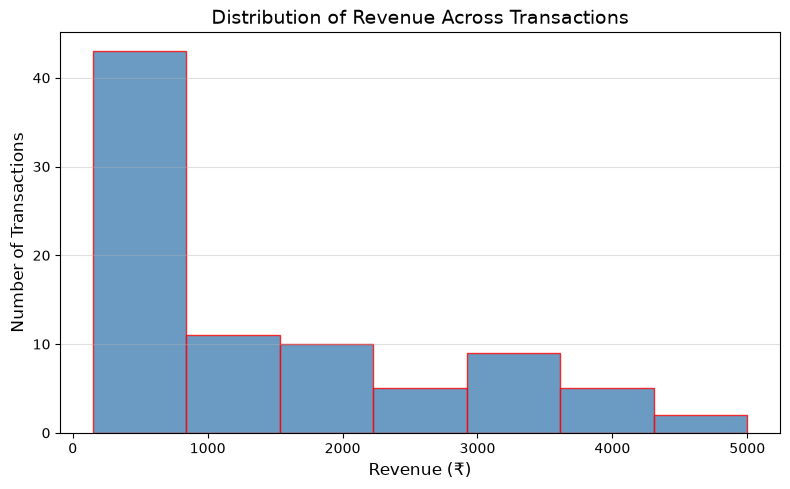

In [12]:
# ============================================
# HISTOGRAM: Distribution of Revenue
# ============================================

plt.figure(figsize=(8, 5))

# bins = number of equal-width buckets to divide the data into
plt.hist(df['Revenue'], bins=7, color='steelblue', edgecolor='red', alpha=0.8)

plt.xlabel('Revenue (₹)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Distribution of Revenue Across Transactions', fontsize=14)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- The **x-axis** shows revenue ranges (bins).
- The **y-axis** shows how many transactions fall in each range.
- If most bars are on the **left side**, the data is **right-skewed** (most transactions have lower revenue, a few have very high).
- A **symmetric** histogram looks like a bell curve.

### 💡 Sample Business Insight

> *"Most transactions generate revenue in the lower range (under ₹2000). A few transactions with high-priced products like Laptops push the tail to the right. This right-skewed distribution is common in retail."*

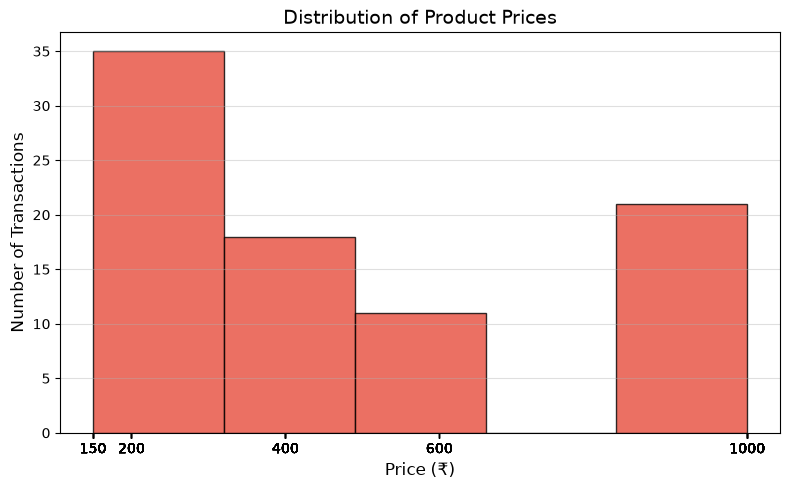

In [13]:
# ============================================
# HISTOGRAM #2: Distribution of Price
# ============================================

plt.figure(figsize=(8, 5))

# Trying different number of bins
plt.hist(df['Price'], bins=5, color='#e74c3c', edgecolor='black', alpha=0.8)

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Distribution of Product Prices', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(df["Price"])
plt.tight_layout()
plt.show()

---

## 11. Boxplot — For Detecting Outliers 📦

**When to use:** When you want to see the **spread of data** and **detect outliers** (unusually high or low values).  
**Business question:** *"Are there any unusually high or low revenue transactions?"*

### Anatomy of a Boxplot:

```
    o           ← Outlier (dot above the whisker)
    |
  ──┬──         ← Maximum (within normal range)
  │   │
  │   │         ← Upper Quartile (Q3 — 75th percentile)
  ├───┤
  │───│         ← Median (Q2 — 50th percentile)
  ├───┤
  │   │         ← Lower Quartile (Q1 — 25th percentile)
  │   │
  ──┴──         ← Minimum (within normal range)
```

- The **box** covers the middle 50% of data (between Q1 and Q3).
- The **line inside** the box is the median.
- The **whiskers** extend to the smallest/largest non-outlier values.
- Any **dots beyond the whiskers** are outliers.

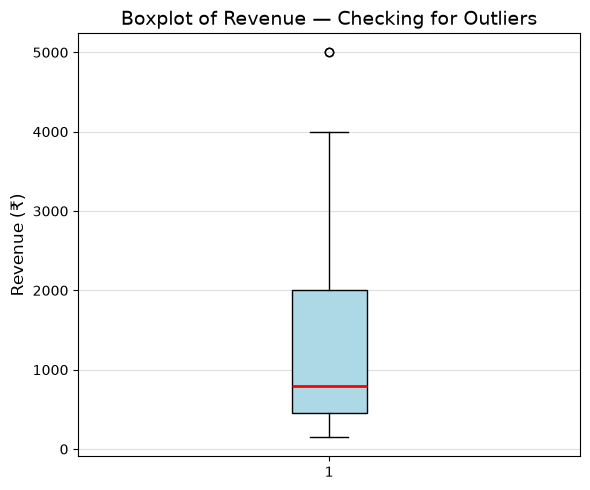

In [14]:
# ============================================
# BOXPLOT: Revenue distribution
# ============================================

plt.figure(figsize=(6, 5))

# Create boxplot
plt.boxplot(df['Revenue'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

#  patch_artist=True allows fill color

plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Boxplot of Revenue — Checking for Outliers', fontsize=14)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- The **red line** inside the box is the **median** revenue.
- The **box** shows where the middle 50% of transactions fall.
- **Dots above or below the whiskers** are potential outliers.
- If there are no dots outside the whiskers, there are no extreme outliers.

### 💡 Sample Business Insight

> *"The median transaction revenue is around ₹900. Most transactions fall between ₹450 and ₹2000. Any transactions beyond the whiskers can be investigated — they may be bulk orders or data entry errors."*

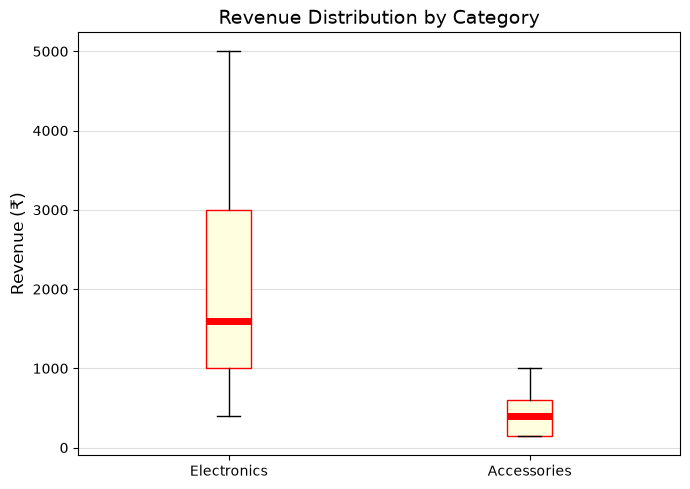

In [15]:
# ============================================
# BOXPLOT #2: Revenue distribution by Category
# ============================================

# Prepare data for each category
electronics_rev = df[df['Category'] == 'Electronics']['Revenue']
accessories_rev = df[df['Category'] == 'Accessories']['Revenue']

plt.figure(figsize=(7, 5))

plt.boxplot([electronics_rev, accessories_rev],
            tick_labels=['Electronics', 'Accessories'],
            patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='red'),
            medianprops=dict(color='red', linewidth=5))

plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Revenue Distribution by Category', fontsize=14)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 💡 Sample Business Insight

> *"Electronics has a much wider revenue range than Accessories, which makes sense since it includes both mid-range products (Smartwatch) and high-end products (Laptop). Accessories revenue is more concentrated in the lower range."*

---

## 12. Making Charts More Professional — Labels, Legend, Grid

Let's combine everything we've learned to make one clean, professional chart.

**The checklist for every chart you create:**
- ✅ `plt.figure(figsize=())` — Set size
- ✅ `plt.xlabel()` — Label x-axis  
- ✅ `plt.ylabel()` — Label y-axis
- ✅ `plt.title()` — Give it a clear title
- ✅ `plt.legend()` — Add legend (when multiple lines/bars)
- ✅ `plt.grid()` — Add gridlines for readability
- ✅ `plt.tight_layout()` — Prevent labels from getting cut off
- ✅ `plt.show()` — Display the chart

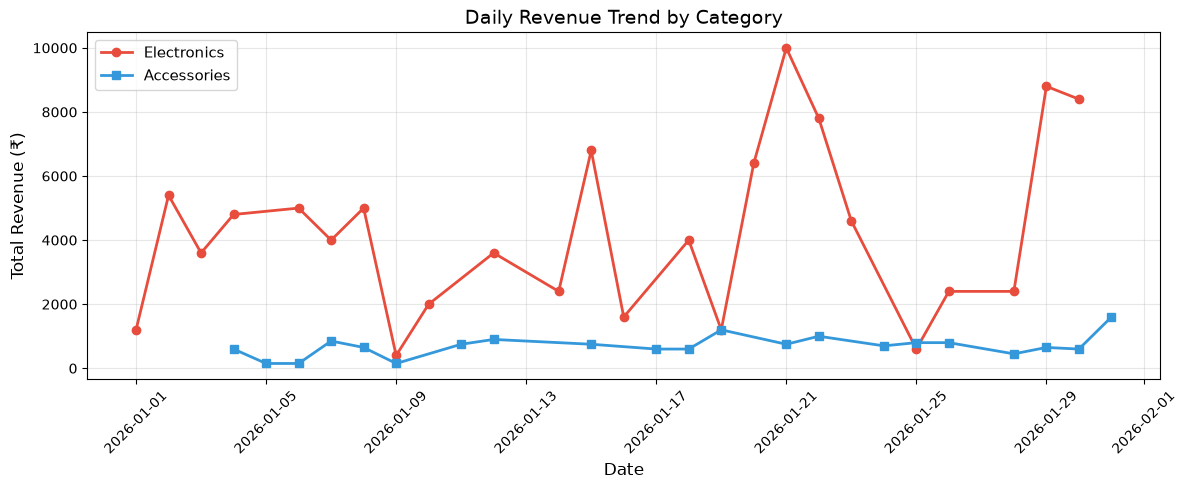

In [16]:
# ============================================
# COMPLETE EXAMPLE: Line chart with all elements
# ============================================

# Prepare data: Daily revenue split by category
electronics_daily = df[df['Category'] == 'Electronics'].groupby('Date')['Revenue'].sum()
accessories_daily = df[df['Category'] == 'Accessories'].groupby('Date')['Revenue'].sum()


# Create the chart
plt.figure(figsize=(12, 5))

# Plot two lines — using 'label' parameter for the legend
plt.plot(electronics_daily.index, electronics_daily.values,
         color='#e74c3c', marker='o', linewidth=2, label='Electronics')

plt.plot(accessories_daily.index, accessories_daily.values,
         color='#3498db', marker='s', linewidth=2, label='Accessories')

# Add all professional elements
plt.xlabel('Date', fontsize=12)                         # X-axis label
plt.ylabel('Total Revenue (₹)', fontsize=12)            # Y-axis label
plt.title('Daily Revenue Trend by Category', fontsize=14)  # Title
plt.legend(fontsize=11)                                 # Show legend
plt.grid(True, alpha=0.3)                               # Gridlines
plt.xticks(rotation=45)                                 # Rotate date labels
plt.tight_layout()                                      # Fix layout

plt.show()

### 💡 Sample Business Insight

> *"Electronics consistently generates higher daily revenue than Accessories. Both categories show fluctuations, but Electronics has more pronounced peaks — likely driven by high-value Laptop and Smartphone sales."*

---

## 14. How to Write Business Insights from Charts

This is one of the **most important skills** in data science. Creating charts is only half the job — the other half is **explaining what the chart tells us**.

### The 3-Step Insight Formula:

| Step | Question to Ask | Example |
|---|---|---|
| 1. **What does the chart show?** | Describe the data | "This bar chart shows total revenue for each product." |
| 2. **What pattern do you see?** | Highlight trends, comparisons, outliers | "Laptop has the highest revenue, followed by Smartphone." |
| 3. **Why does it matter?** | Connect to business impact | "The business should ensure Laptop inventory is always stocked." |

### ❌ Bad insight:
> *"The bar chart shows revenue."*

### ✅ Good insight:
> *"Laptop dominates revenue at ₹X, contributing Y% of total sales. Given its high margin, prioritizing Laptop marketing campaigns could boost overall profitability."*

### Practice:
Go back to each chart we created and try writing your own 1–2 line insight!

---

## 13. Subplots — Multiple Charts in One Figure 🔲

So far we have created **one chart at a time** using `plt.figure()` and `plt.show()`.  
But in real-world analysis, you often need to **compare multiple charts side by side**.  
That's where **subplots** come in!

### What are Subplots?

A **subplot** is simply a chart that lives inside a **grid** within a single figure.  
Think of the figure as a **canvas** and each subplot as a **panel** on that canvas.

### How `plt.subplots()` works

```python
fig, axes = plt.subplots(nrows, ncols, figsize=(width, height))
```

| Parameter | Meaning |
|---|---|
| `nrows` | Number of **rows** in the grid |
| `ncols` | Number of **columns** in the grid |
| `figsize` | Overall figure size in inches (width, height) |
| `fig` | The **Figure** object — the entire canvas |
| `axes` | A single **Axes** object or an **array of Axes** — each one is a subplot |

**Key points:**
- When `nrows=1` and `ncols=1`, `axes` is a *single* Axes object.  
- When either `nrows` or `ncols` is > 1, `axes` becomes a **1-D NumPy array**.  
- When **both** are > 1, `axes` becomes a **2-D NumPy array** (row, col).  
- Use `fig.suptitle()` to add a **main title** for the whole figure.  
- Use `fig.tight_layout()` to **automatically adjust** spacing so labels don't overlap.


### Example 1 — Two Charts Side by Side (1 row × 2 columns)

**Business question:** *"How do daily revenue trends and the revenue distribution compare?"*

Instead of creating two separate figures, we place a **Line Chart** and a **Histogram** next to each other.

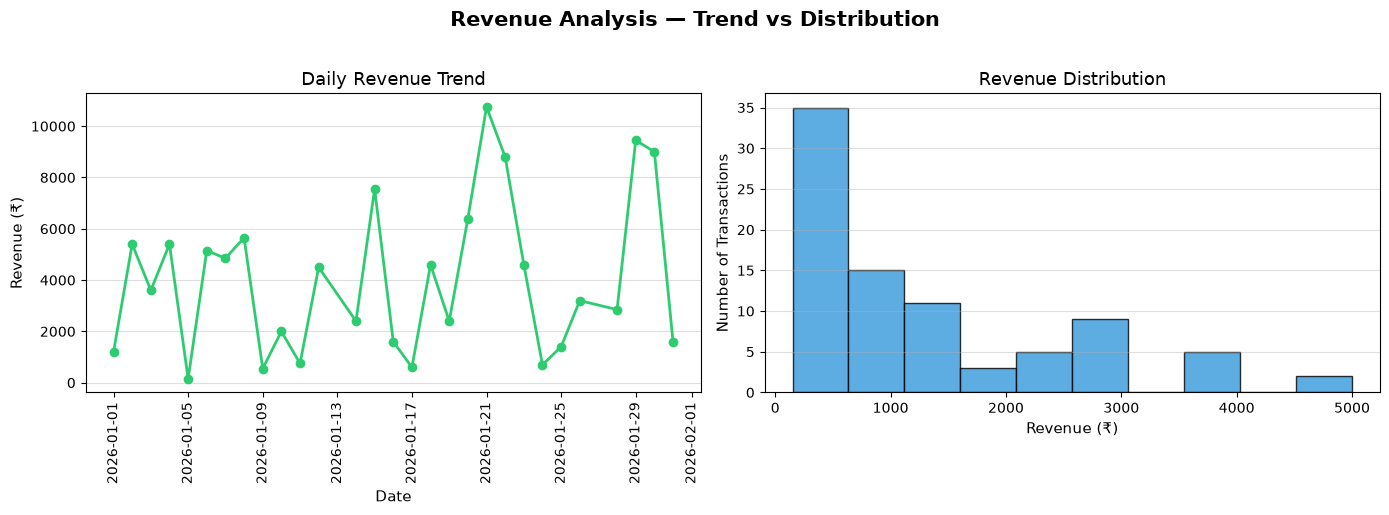

In [17]:
# ============================================
# SUBPLOTS EXAMPLE 1: 1 row × 2 columns
# Line chart + Histogram side by side
# ============================================

# Prepare data
daily_revenue = df.groupby('Date')['Revenue'].sum()

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Left subplot (axes[0]): Line chart ---
axes[0].plot(daily_revenue.index, daily_revenue.values,
             color='#2ecc71', marker='o', linewidth=2)
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Revenue (₹)', fontsize=11)
axes[0].set_title('Daily Revenue Trend', fontsize=13)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', alpha=0.4)

# --- Right subplot (axes[1]): Histogram ---
axes[1].hist(df['Revenue'], bins=10, color='#3498db',
             edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Revenue (₹)', fontsize=11)
axes[1].set_ylabel('Number of Transactions', fontsize=11)
axes[1].set_title('Revenue Distribution', fontsize=13)
axes[1].grid(axis='y', alpha=0.4)

# Add a main title for the whole figure
fig.suptitle('Revenue Analysis — Trend vs Distribution',
             fontsize=15, fontweight='bold', y=1.02)

# Adjust layout so nothing overlaps
fig.tight_layout()
plt.show()

### 📝 How to Read This

- The **left panel** shows the revenue trend over time — you can spot spikes and dips at a glance.
- The **right panel** shows how revenue values are distributed — you can see which revenue range is most common.
- Placing them **side by side** makes the comparison instant, instead of scrolling between two separate charts.

### 💡 Sample Business Insight

> *"While daily revenue fluctuates heavily (left), the histogram (right) shows that most transactions fall in the lower revenue range, with a few high-value outliers driving the spikes."*

### Example 2 — A 2×2 Grid of Charts

**Business question:** *"Can I get a quick overview of revenue using four different chart types in one view?"*

With a **2×2 grid**, you can fit four charts in a single figure.  
Notice that with `nrows=2, ncols=2`, `axes` becomes a **2-D array**, so you access each subplot with `axes[row][col]`.

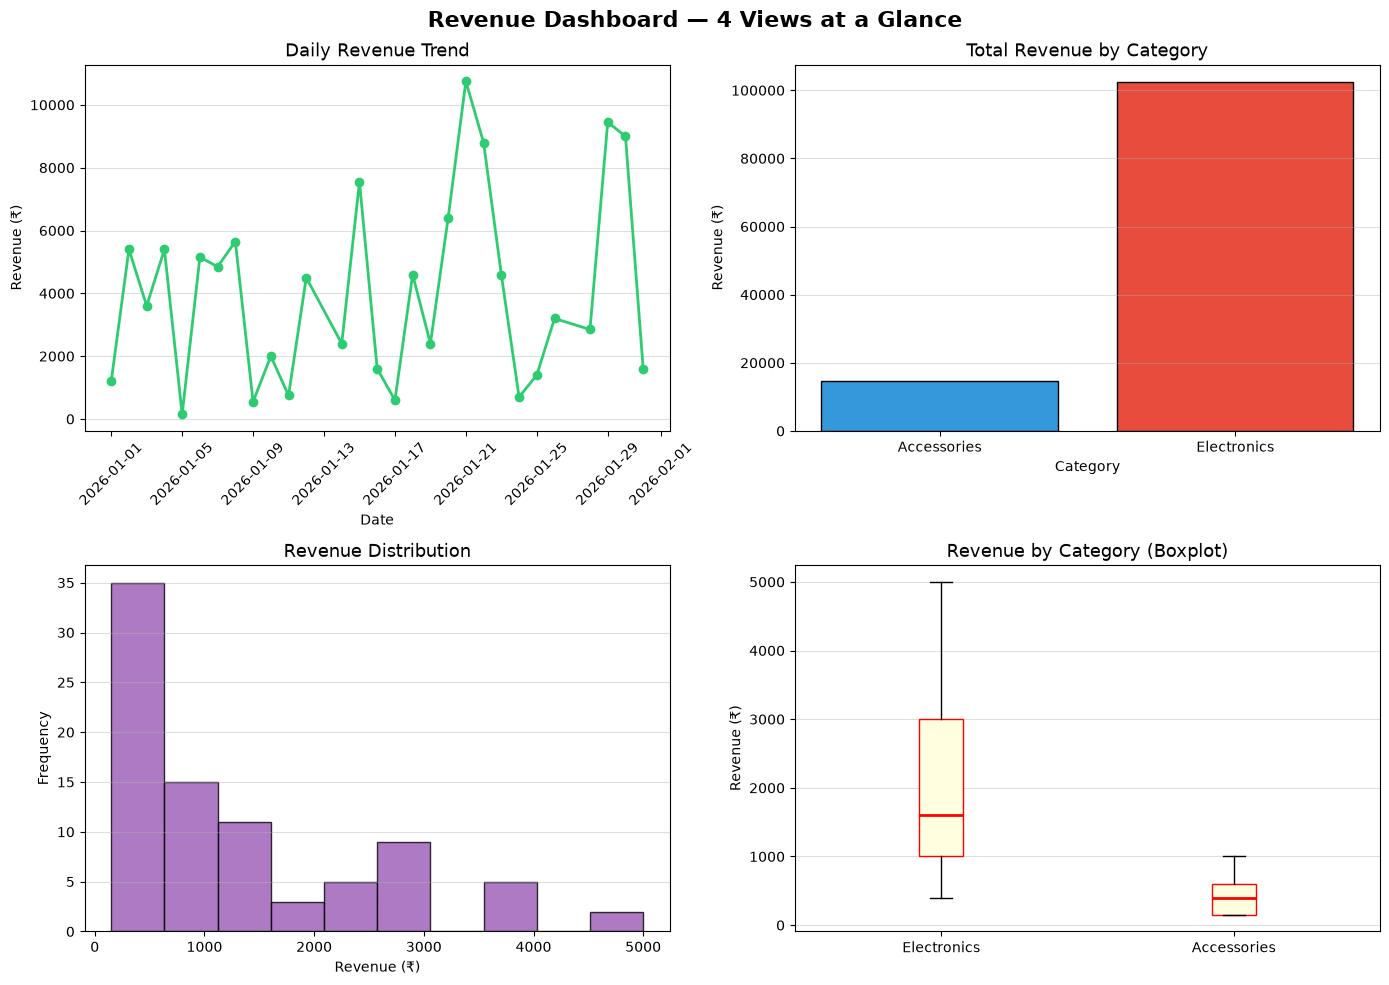

In [18]:
# ============================================
# SUBPLOTS EXAMPLE 2: 2 rows × 2 columns
# Line chart, Bar chart, Histogram, Boxplot
# ============================================

# Prepare data
daily_revenue = df.groupby('Date')['Revenue'].sum()
category_revenue = df.groupby('Category')['Revenue'].sum()

# Create a 2×2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# --- Top-left (axes[0][0]): Line chart ---
axes[0][0].plot(daily_revenue.index, daily_revenue.values,
                color='#2ecc71', marker='o', linewidth=2)
axes[0][0].set_title('Daily Revenue Trend', fontsize=13)
axes[0][0].set_xlabel('Date', fontsize=10)
axes[0][0].set_ylabel('Revenue (₹)', fontsize=10)
axes[0][0].tick_params(axis='x', rotation=45)
axes[0][0].grid(axis='y', alpha=0.4)

# --- Top-right (axes[0][1]): Bar chart ---
colors = ['#3498db', '#e74c3c']
axes[0][1].bar(category_revenue.index, category_revenue.values,
               color=colors, edgecolor='black')
axes[0][1].set_title('Total Revenue by Category', fontsize=13)
axes[0][1].set_xlabel('Category', fontsize=10)
axes[0][1].set_ylabel('Revenue (₹)', fontsize=10)
axes[0][1].grid(axis='y', alpha=0.4)

# --- Bottom-left (axes[1][0]): Histogram ---
axes[1][0].hist(df['Revenue'], bins=10, color='#9b59b6',
                edgecolor='black', alpha=0.8)
axes[1][0].set_title('Revenue Distribution', fontsize=13)
axes[1][0].set_xlabel('Revenue (₹)', fontsize=10)
axes[1][0].set_ylabel('Frequency', fontsize=10)
axes[1][0].grid(axis='y', alpha=0.4)

# --- Bottom-right (axes[1][1]): Boxplot ---
electronics_rev = df[df['Category'] == 'Electronics']['Revenue']
accessories_rev = df[df['Category'] == 'Accessories']['Revenue']
axes[1][1].boxplot([electronics_rev, accessories_rev],
                   tick_labels=['Electronics', 'Accessories'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightyellow', color='red'),
                   medianprops=dict(color='red', linewidth=2))
axes[1][1].set_title('Revenue by Category (Boxplot)', fontsize=13)
axes[1][1].set_ylabel('Revenue (₹)', fontsize=10)
axes[1][1].grid(axis='y', alpha=0.4)

# Add main title and adjust spacing
fig.suptitle('Revenue Dashboard — 4 Views at a Glance',
             fontsize=16, fontweight='bold')

fig.tight_layout()
plt.show()

### 📝 `plt.subplots()` vs `plt.figure()` — When to Use Which

| Feature | `plt.figure()` + `plt.plot()` | `plt.subplots()` |
|---|---|---|
| Number of charts | **One** chart per figure | **Multiple** charts per figure |
| Access style | Use `plt.xlabel()`, `plt.title()` etc. | Use `ax.set_xlabel()`, `ax.set_title()` etc. |
| Best for | Quick, single-chart exploration | Comparing related charts side by side |
| Layout control | Minimal | Full grid control (rows × columns) |

**Tip:**  
- When using `plt.subplots()`, each subplot is an **Axes object** (`ax`).  
- Instead of `plt.xlabel()`, you use `ax.set_xlabel()`.  
- Instead of `plt.title()`, you use `ax.set_title()`.  
- This is known as the **object-oriented (OO) interface** of Matplotlib.  
- It gives you much **finer control** over each individual chart.

### 💡 Sample Business Insight

> *"The 2×2 dashboard gives a quick, at-a-glance summary of our retail sales data. The line chart reveals revenue volatility, the bar chart shows Electronics dominating total revenue, the histogram confirms most transactions are low-value, and the boxplot highlights that Electronics has both higher median revenue and more spread than Accessories."*

---

## 15. Quick Reference — Chart Selection Guide

| Question Type | Chart Type | Matplotlib Function |
|---|---|---|
| How does it change **over time**? | Line Chart | `plt.plot()` |
| Which one is **bigger/smaller**? | Bar Chart | `plt.bar()` or `plt.barh()` |
| Is there a **relationship** between two numbers? | Scatter Plot | `plt.scatter()` |
| How is the data **distributed**? | Histogram | `plt.hist()` |
| Are there **outliers**? | Boxplot | `plt.boxplot()` |

**Remember:** Always add `xlabel`, `ylabel`, `title`, and `grid` to make your charts professional!

---

## 📝 Practice Questions

Try these on your own using the same Retail Sales dataset:

1. **Line Chart:** Plot the daily total quantity sold over time. Add title, labels, and grid.

2. **Bar Chart:** Create a bar chart showing the **average revenue** per product (not total — use `.mean()` instead of `.sum()`). Which product has the highest average revenue?

3. **Bar Chart:** Create a horizontal bar chart showing the **number of transactions** per product (use `value_counts()`).

4. **Scatter Plot:** Create a scatter plot of `Quantity` vs `Price`. Is there any relationship?

5. **Histogram:** Plot the distribution of `Quantity` with `bins=5`. Is the distribution uniform or skewed?

6. **Boxplot:** Create a boxplot of `Price`. Are there any price outliers?

7. **Insight Writing:** For **any 2 charts** you created above, write a 2-line business insight using the 3-step formula (What → Pattern → Business Impact).

8. **Combined Chart:** Create a line chart showing daily average price over time. Add a descriptive title and grid.

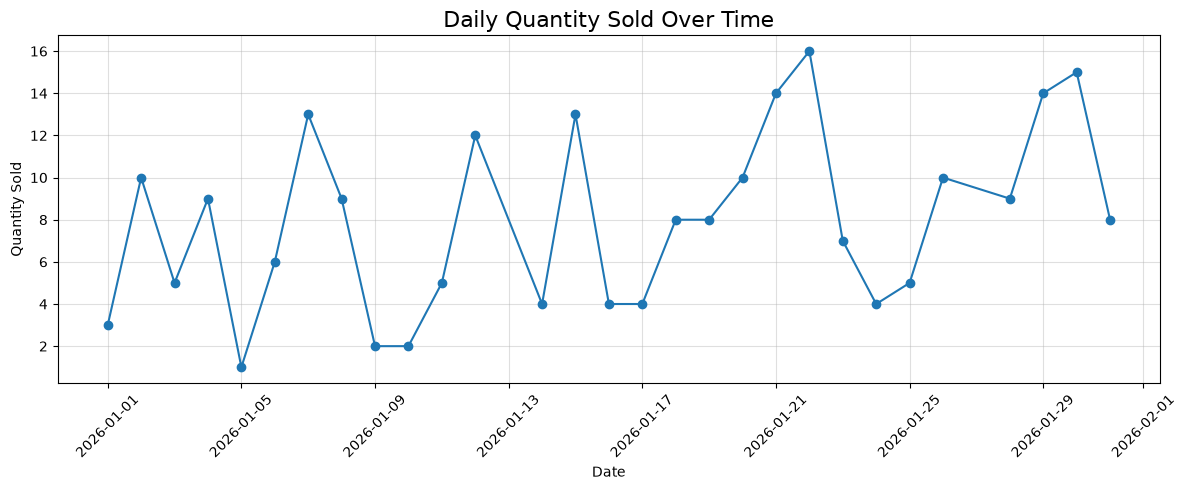

In [19]:
# ============================================
# YOUR PRACTICE SPACE — Question 1
# ============================================
# Convert Order Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Group by date and sum the quantity sold each day
daily_quantity = df.groupby('Date')['Quantity'].sum()

# Plot
plt.figure(figsize=(12,5))
plt.plot(daily_quantity.index, daily_quantity.values, marker='o')
plt.title("Daily Quantity Sold Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.grid(alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

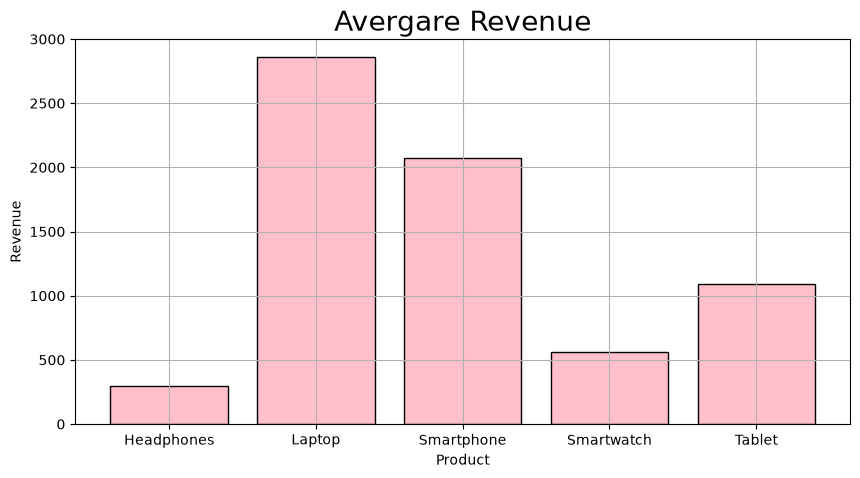

In [20]:
# ============================================
# YOUR PRACTICE SPACE — Question 2
# ============================================
average_revenue=df.groupby('Product')['Revenue'].mean()
# Write your code here
plt.figure(figsize=(10,5))
plt.bar(average_revenue.index,average_revenue.values,color='pink', edgecolor='black')
plt.title("Avergare Revenue", fontsize=20,color='black')
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()



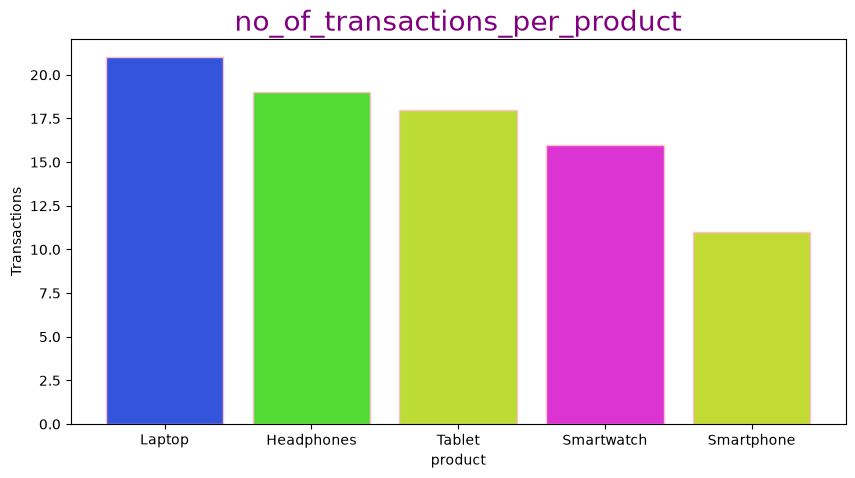

In [21]:
# ============================================
# YOUR PRACTICE SPACE — Question 3
# ============================================
no_of_transactions_per_product=df['Product'].value_counts()
plt.figure(figsize=(10,5))
color=[ "#3455db","#53db34","#bcdb34","#db34d3","#c2db34"]
plt.bar(no_of_transactions_per_product.index,no_of_transactions_per_product.values,color=color,edgecolor='pink')
plt.title("no_of_transactions_per_product",fontsize=20,color="Purple")
plt.xlabel("product")
plt.ylabel('Transactions')
plt.show()
# Write your code here


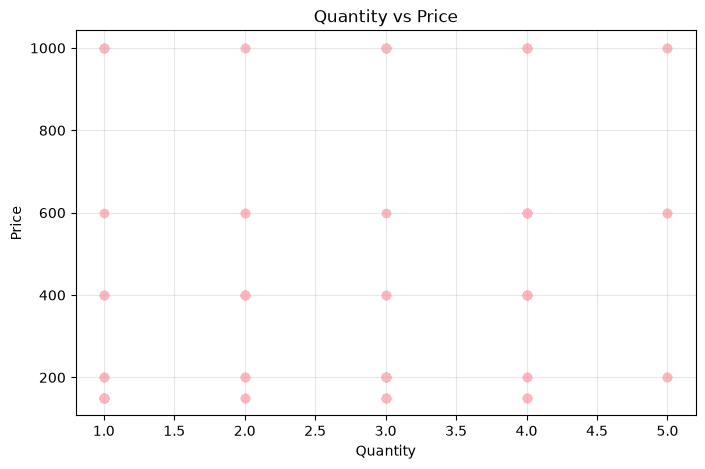

In [22]:
# ============================================
# YOUR PRACTICE SPACE — Question 4
# ============================================
# 4. **Scatter Plot:** Create a scatter plot of `Quantity` vs `Price`. Is there any relationship?

# Write your code here
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Price'],color='lightpink', alpha=1)

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Quantity vs Price")
plt.grid(alpha=0.3)

plt.show()

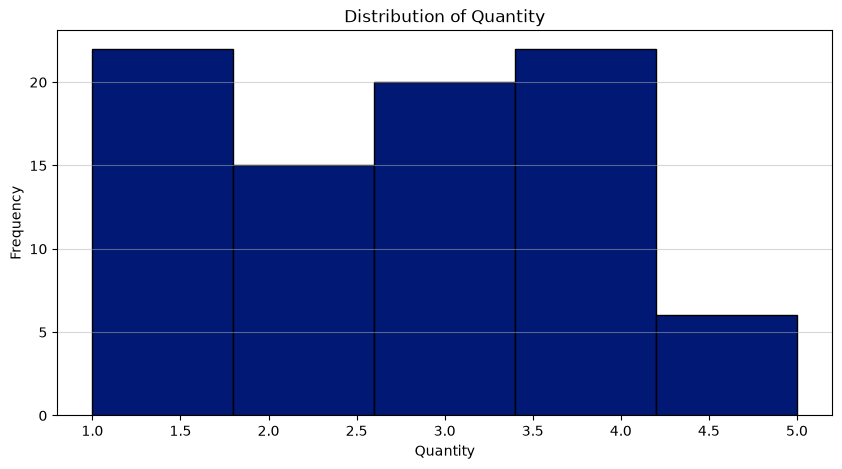

In [23]:
# ============================================
# YOUR PRACTICE SPACE — Question 5
# ============================================
# **Histogram:** Plot the distribution of `Quantity` with `bins=5`. Is the distribution uniform or skewed?
# Write your code here
import matplotlib.pyplot as plt
color="#011875"
plt.figure(figsize=(10,5))
plt.hist(df['Quantity'], bins=5,color=color, edgecolor='black')

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")

plt.grid(axis='y', alpha=0.5)
plt.show()
#skewwed distribution

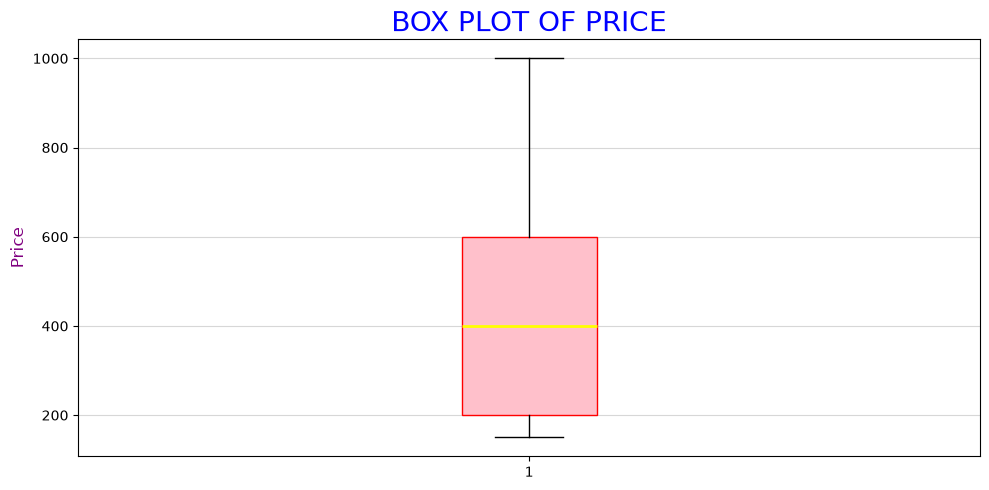

In [24]:
# ============================================
# YOUR PRACTICE SPACE — Question 6
# ============================================
#6. **Boxplot:** Create a boxplot of `Price`. Are there any price outliers?
# Write your code here
plt.figure(figsize=(10,5))
plt.boxplot(df['Price'],patch_artist=True,boxprops=dict(facecolor='pink',edgecolor='red'),
            medianprops=dict(color='yellow',linewidth=2))
plt.ylabel("Price",fontsize=12,color='purple')
plt.title("BOX PLOT OF PRICE",color='Blue',fontsize=20)
plt.grid(axis='y',alpha=0.5)
plt.tight_layout()
plt.show()


In [25]:
# ============================================
# YOUR PRACTICE SPACE — Question 7 (Insights)
# ============================================
#""" 7. **Insight Writing:** For **any 2 charts** you 
#created above, write a 2-line business insight using the 3-step formula (What → Pattern → Business Impact)."""
print("Histogram Insight:")
print("What: Most orders have low quantities, while only a few have high quantities.")
print("Pattern → Business Impact: The distribution is right-skewed, indicating customers usually buy fewer items. Bundle offers or quantity discounts can encourage larger purchases.\n")

print("Boxplot Insight:")
print("What: Most product prices fall within a similar range, with a few price outliers.")
print("Pattern → Business Impact: The outliers represent premium or unusually priced products. Reviewing their pricing strategy can help maximize profitability.")

Histogram Insight:
What: Most orders have low quantities, while only a few have high quantities.
Pattern → Business Impact: The distribution is right-skewed, indicating customers usually buy fewer items. Bundle offers or quantity discounts can encourage larger purchases.

Boxplot Insight:
What: Most product prices fall within a similar range, with a few price outliers.
Pattern → Business Impact: The outliers represent premium or unusually priced products. Reviewing their pricing strategy can help maximize profitability.


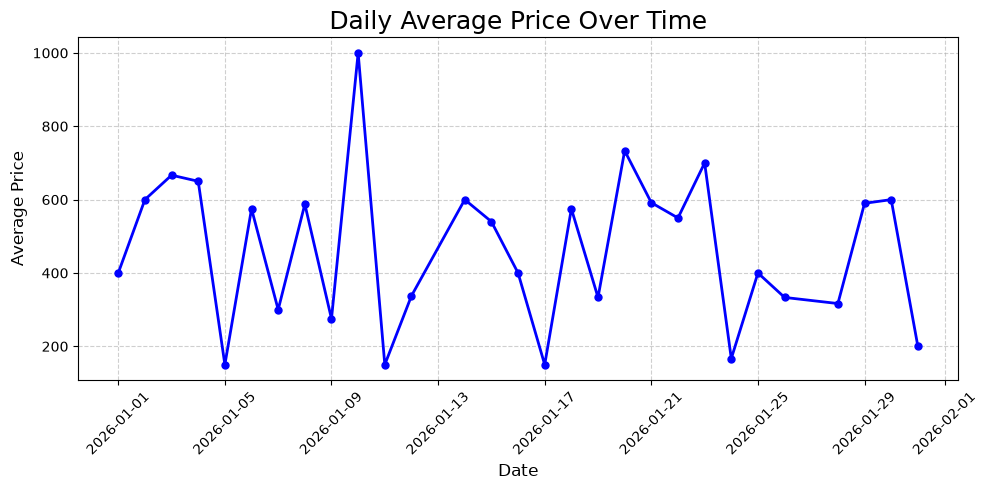

In [27]:
# ============================================
# YOUR PRACTICE SPACE — Question 8
# ============================================
#8. **Combined Chart:**
#  Create a line chart showing daily average price over time. Add a descriptive title and grid.
# Write your code here
daily_avg_price = df.groupby('Date')['Price'].mean()
import matplotlib.pyplot as plt

# Calculate daily average price
daily_avg_price = df.groupby('Date')['Price'].mean()

# Line chart
plt.figure(figsize=(10,5))

plt.plot(
    daily_avg_price.index,
    daily_avg_price.values,
    color='blue',
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title("Daily Average Price Over Time", fontsize=18)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---

## 🎯 Assignment: Mini Visualization Report

**Objective:** Create a mini visualization report for the Retail Sales dataset.

**Instructions:**

1. Create the following 4 charts using the Retail Sales dataset:
   - A **line chart** showing total revenue by day
   - A **bar chart** showing average quantity sold per product
   - A **histogram** showing the distribution of revenue
   - A **boxplot** comparing revenue across products (create 5 separate lists, one per product)

2. For **each chart**, ensure you have:
   - Proper `figsize`
   - `xlabel`, `ylabel`, and `title`
   - `grid`

3. After **each chart**, write a **2–3 sentence business insight** explaining:
   - What the chart shows
   - What pattern you observe
   - One business recommendation

**Submission:** Complete the assignment in a new notebook or in the cells below.

---

## ✅ Summary

In this notebook, we learned:

| Topic | What We Covered |
|---|---|
| **Why Visualize** | Charts reveal patterns that tables hide |
| **Line Chart** | For trends over time (`plt.plot()`) |
| **Bar Chart** | For comparing categories (`plt.bar()`) |
| **Scatter Plot** | For relationships between numbers (`plt.scatter()`) |
| **Histogram** | For data distribution (`plt.hist()`) |
| **Boxplot** | For outlier detection (`plt.boxplot()`) |
| **Professional charts** | Always add `xlabel`, `ylabel`, `title`, `legend`, `grid` |
| **Business insights** | What → Pattern → Business Impact |

**Next up:** Seaborn — create the same charts with less code and better styling! 🎨

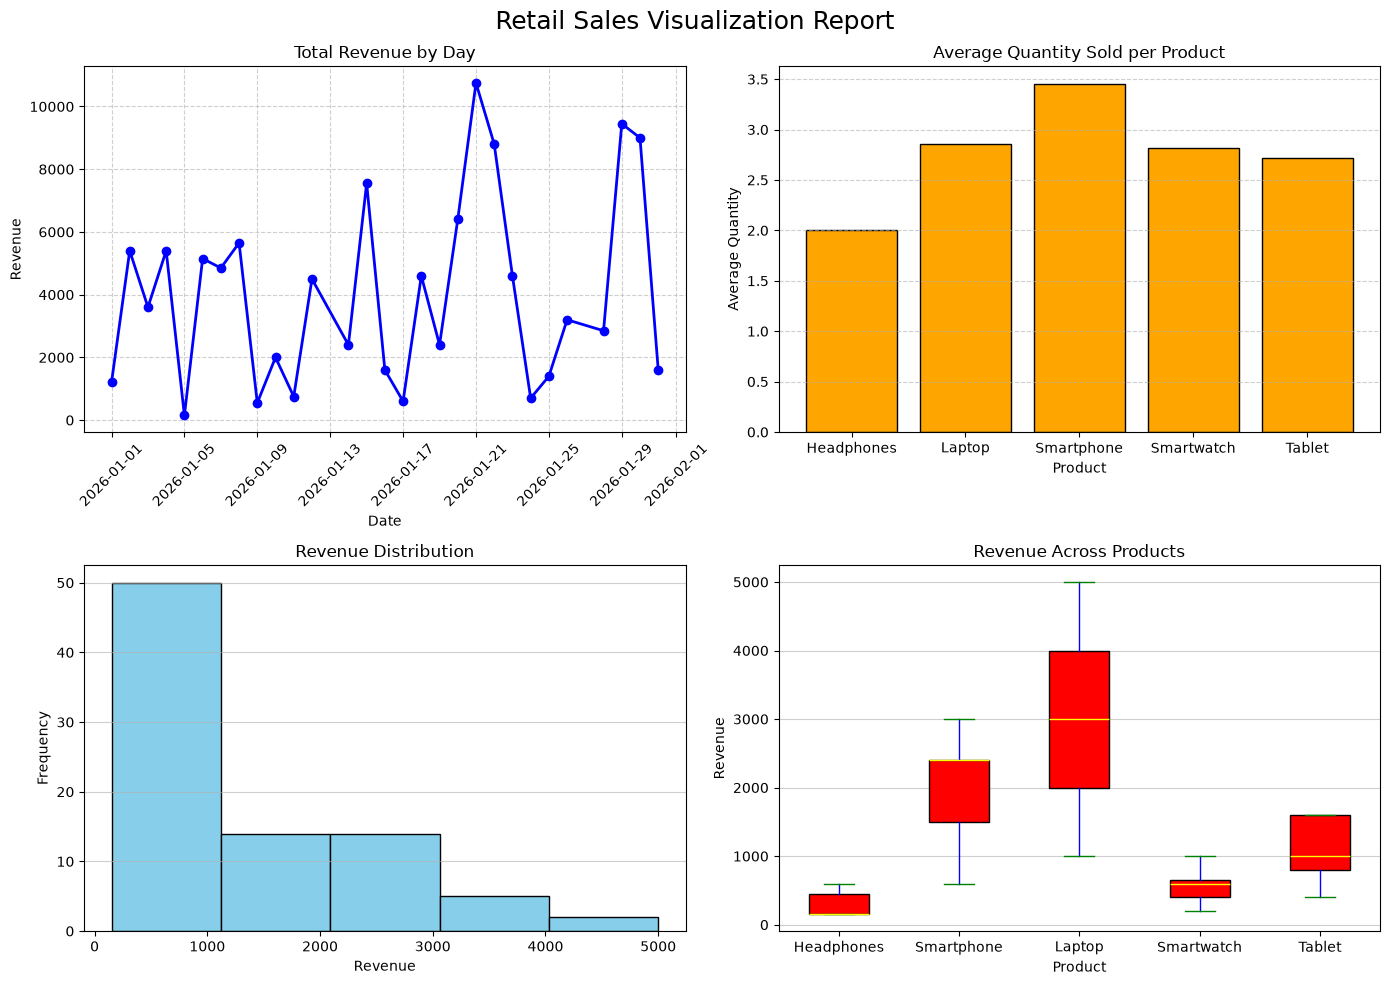

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(14,10))

# 1. Line Chart
daily_revenue = df.groupby('Date')['Revenue'].sum()

ax[0,0].plot(daily_revenue.index, daily_revenue.values,
             marker='o', color='blue', linewidth=2)
ax[0,0].set_title("Total Revenue by Day")
ax[0,0].set_xlabel("Date")
ax[0,0].set_ylabel("Revenue")
ax[0,0].grid(True, linestyle='--', alpha=0.6)
ax[0,0].tick_params(axis='x', rotation=45)

# 2. Bar Chart
avg_quantity = df.groupby('Product')['Quantity'].mean()

ax[0,1].bar(avg_quantity.index, avg_quantity.values,
            color='orange', edgecolor='black')
ax[0,1].set_title("Average Quantity Sold per Product")
ax[0,1].set_xlabel("Product")
ax[0,1].set_ylabel("Average Quantity")
ax[0,1].grid(axis='y', linestyle='--', alpha=0.6)

# 3. Histogram
ax[1,0].hist(df['Revenue'], bins=5,
             color='skyblue', edgecolor='black')
ax[1,0].set_title("Revenue Distribution")
ax[1,0].set_xlabel("Revenue")
ax[1,0].set_ylabel("Frequency")
ax[1,0].grid(axis='y', alpha=0.6)

# 4. Boxplot
products = df['Product'].unique()

revenue_data = [df[df['Product'] == p]['Revenue'] for p in products]

ax[1,1].boxplot(
    revenue_data,
    tick_labels=products,
    patch_artist=True,
    boxprops=dict(facecolor='red', color='black'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='green'),
    flierprops=dict(marker='o', markerfacecolor='purple')
)

ax[1,1].set_title("Revenue Across Products")
ax[1,1].set_xlabel("Product")
ax[1,1].set_ylabel("Revenue")
ax[1,1].grid(axis='y', alpha=0.6)

fig.suptitle("Retail Sales Visualization Report", fontsize=18)
plt.tight_layout()
plt.show()